# Machine Learning Final Project : Nutrient Regression
**Logan Dawes** - CS4783

The goal of this project is to develop a machine learning model for both classification and prediction tasks. The model will be designed to automatically infer missing ingredient lists and nutrient information for a given food item. This enables it to perform ingredient classification as well as nutrient estimation

### Import Libraries

In [1]:
%reset -f

In [ ]:
# Import data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import other libraries
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import json
import gc

# Import TensorFlow and Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

### Load Cleaned Dataset

First we will load the cleaned and prepared data from the EDA & Feature Engineering notebook.

For this model, we will load the nutrient amount columns as the ones to predict.

For the sake of demonstration, we will only attempt to predict columns that are more than 90% missing, due to the very sparse data.

For better model performance, we will also drop ingredient one-hot encoded that are more than 90% zero.

In [4]:
# Load datatypes for final_food_data
with open('final_food_data_dtypes.json', 'r') as f:
    final_food_data_dtypes = json.load(f)

# Load processed dataset
food_data = pd.read_csv('final_food_data.csv', dtype=final_food_data_dtypes)

# Select all nutrient amount columns (exclude logs and package weight)
nutrient_candidates = [col for col in food_data.columns if 'amount' in col and not col.endswith('_log') and not col == 'package_weight_amount']
print('Zero percentage for each nutrient candidate:')
nutrient_cols = []
failed_nutrient_cols = set()
for col in nutrient_candidates:
    zero_pct = (food_data[col] == 0).mean() * 100
    print(f'{col}: {zero_pct:.2f}% zero')
    if zero_pct <= 90:
        nutrient_cols.append(col)
    else:
        failed_nutrient_cols.add(col)
print(f'Total nutrient candidates: {len(nutrient_candidates)}')
print(f'Nutrient columns ({len(nutrient_cols)}): {nutrient_cols}')

# Select all one-hot ingredient columns
ingredient_oh_cols = [col for col in food_data.columns if col.startswith('ingredient_oh_')]
print(f'Ingredient one-hot columns: {ingredient_oh_cols[:10]} ... total: {len(ingredient_oh_cols)}')

# Drop ingredient one-hot columns with >90% zeros
filtered_ingredient_oh_cols = [
    col for col in ingredient_oh_cols
    if (food_data[col] == 0).mean() <= 0.9
]
failed_ingredient_oh_cols = set(ingredient_oh_cols) - set(filtered_ingredient_oh_cols)
print(f'Filtered ingredient one-hot columns: {filtered_ingredient_oh_cols[:10]} ... total: {len(filtered_ingredient_oh_cols)}')

Zero percentage for each nutrient candidate:
Acetic acid amount: 100.00% zero
Alanine amount: 99.98% zero
Alcohol, ethyl amount: 100.00% zero
Arginine amount: 99.98% zero
Ash amount: 99.82% zero
Aspartic acid amount: 99.98% zero
Beta-glucans amount: 100.00% zero
Biotin amount: 99.80% zero
Caffeine amount: 99.96% zero
Calcium, Ca amount: 44.51% zero
Carbohydrate, by difference amount: 15.33% zero
Carbohydrate, other amount: 99.77% zero
Carotene, beta amount: 100.00% zero
Chlorine, Cl amount: 99.92% zero
Cholesterol amount: 66.02% zero
Choline, from phosphotidyl choline amount: 100.00% zero
Choline, total amount: 99.94% zero
Chromium, Cr amount: 99.90% zero
Copper, Cu amount: 98.95% zero
Cysteine amount: 99.99% zero
Cystine amount: 99.99% zero
Energy amount: 11.22% zero
Epigallocatechin-3-gallate amount: 100.00% zero
Fatty acids, total monounsaturated amount: 91.02% zero
Fatty acids, total polyunsaturated amount: 91.20% zero
Fatty acids, total saturated amount: 46.82% zero
Fatty acids, t

In [5]:
# Prepare input features (exclude nutrient columns and failed ingredient one-hot columns)
exclude_cols = set(nutrient_cols)
exclude_cols.update(failed_ingredient_oh_cols)
exclude_cols.update(failed_nutrient_cols)
feature_cols = [col for col in food_data.columns if col not in exclude_cols]

# Memory cleanup after data loading
def memory_cleanup(data):
    for var in data:
        if var in locals():
            del globals()[var]
    gc.collect()
    
memory_cleanup(['final_food_data_dtypes', 'f', 'exclude_cols'])

## Step 1: Train/Test Split

Before preparing the train and test split for the data, we will define a batch generator function that will load a batch of data into the model. This is for memory efficiency.

In [6]:
# Batch generator for memory-efficient training
def batch_generator(data, feature_cols, nutrient_cols, window_size=3, batch_size=128):
    num_rows = len(data)
    while True:
        for start in range(window_size, num_rows, batch_size):
            end = min(start + batch_size, num_rows)
            X_batch = []
            y_batch = []
            for i in range(start, end):
                X_window = data.iloc[i-window_size:i][feature_cols].values
                y_row = data.iloc[i][nutrient_cols].values
                X_batch.append(X_window)
                y_batch.append(y_row)
            yield np.array(X_batch), np.array(y_batch)

Now, the following code calculates the split index for an 80/20 train/test split, accounting for the window size used in the batch generator.

 It then creates memory-efficient batch generators for both the training and testing sets, which will be used to feed data into the model during training and evaluation.
 
  The code also computes the number of steps per epoch for both sets, ensuring that the model trains and validates on the correct number of batches.

In [7]:
# Set window size and batch size
window_size = 3
batch_size = 128

# Calculate split index for train/test
num_rows = len(food_data)
split_idx = int((num_rows - window_size) * 0.8)
print(f'[Split] Total rows: {num_rows}, Train rows: {split_idx + window_size}, Test rows: {num_rows - split_idx}')

# Define train and test generators
train_gen = batch_generator(
    food_data.iloc[:split_idx + window_size],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)
test_gen = batch_generator(
    food_data.iloc[split_idx:],
    feature_cols,
    nutrient_cols,
    window_size=window_size,
    batch_size=batch_size
)

# Calculate steps per epoch
train_steps = (split_idx) // batch_size
test_steps = (num_rows - window_size - split_idx) // batch_size
print(f'[Steps] Train steps per epoch: {train_steps}, Test steps: {test_steps}')

[Split] Total rows: 1977398, Train rows: 1581919, Test rows: 395482
[Steps] Train steps per epoch: 12358, Test steps: 3089


## Step 2: Build the Model

### Explanation of LSTM Model Architecture

The `make_lstm_model` function builds a neural network for multi-output regression using the following layers and techniques:

**Why LSTM?**  
LSTM (Long Short-Term Memory) networks are designed to capture temporal dependencies in sequential data. In this project, food ingredient and nutrient information can have patterns over ordered samples. LSTMs are well-suited for learning these relationships, making them a good choice for modeling sequences where past context influences predictions.

**Window Size Meaning:**  
The window size determines how many consecutive samples are fed into the model at once. Here, a window size of 3 means the model considers the current sample and the previous two samples together, allowing it to learn short-term trends and dependencies in the input features that may affect nutrient predictions.

**1. Input Layer:**
- Specifies the input shape as `(window_size, feature_count)`, allowing the model to process sequences of features.

**2. LSTM Layers:**
- The first LSTM layer (`units_1`) captures temporal dependencies in the input sequence and outputs a sequence for further processing.
- The second LSTM layer (`units_2`) processes the output from the first LSTM and returns a single vector, summarizing the learned sequence features.

**3. Dropout Layers:**
- Dropout (`dropout_1` and `dropout_2`) randomly sets a fraction of input units to zero during training, helping prevent overfitting by making the model less sensitive to specific weights.

**4. Batch Normalization:**
- Batch normalization normalizes the output of the previous layer, speeding up training and improving stability.

**5. Dense Output Layer:**
- The final dense layer outputs predictions for all nutrient targets. It uses L2 regularization (`kernel_regularizer=l2_reg`) to penalize large weights, further reducing overfitting.
- The activation function is `softplus`, which outputs positive values and is smooth, making it suitable for regression tasks where outputs should be non-negative.

**6. Optimizer and Loss Function:**
- The model uses the Adam optimizer, which adapts learning rates for each parameter and generally converges faster than standard gradient descent.
- The loss function is Mean Squared Error (`mean_absolute_error`), which measures the average absolute difference between predicted and true values, which differs from mean squared error in that it does not heavily penalize outliers in the data.

Together, these layers and techniques allow the model to learn complex temporal and feature relationships in the data, while regularization and normalization help ensure generalization and stable training.

### Build the Model

In [ ]:
# Utility function to build and compile LSTM model
def make_lstm_model(window_size, feature_count, output_count, units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate):
    model = Sequential()
    model.add(Input(shape=(window_size, feature_count)))
    model.add(LSTM(units=units_1, return_sequences=True))
    model.add(Dropout(dropout_1))
    model.add(BatchNormalization())
    model.add(LSTM(units=units_2))
    model.add(Dropout(dropout_2))
    model.add(BatchNormalization())
    model.add(Dense(output_count, kernel_regularizer=l2_reg, activation='softplus'))
    adam_opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam_opt, loss='mean_absolute_error') # Difference: Loss function
    return model

### KerasTuner Hyperparameter Search

KerasTuner was used previously to automate the search for optimal hyperparameters for the LSTM model. It tested different combinations of LSTM units, dropout rates, and learning rates to find the configuration that minimized validation loss.

It is now disabled to save time, the hyperparameters from the trials are used.

In [ ]:
'''
# Define a model-building function for KerasTuner
def build_lstm_model(hp):
    l2_reg = regularizers.l2(0.001)
    units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model = make_lstm_model(
        window_size,
        len(feature_cols),
        len(nutrient_cols),
        units_1,
        units_2,
        dropout_1,
        dropout_2,
        l2_reg,
        learning_rate
    )
    return model
'''

In [ ]:
'''
# Set up KerasTuner for hyperparameter search
tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=1,
    directory='kt_lstm_tuning',
    project_name='nutrient_lstm',
    overwrite=True,
    seed=42,
    )
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print('[KerasTuner] Starting hyperparameter search...')
tuner.search(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=test_gen,
    validation_steps=test_steps,
    epochs=5,
    callbacks=[early_stop]
    )
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('[KerasTuner] Best hyperparameters found:')
for param in best_hp.values.keys():
    print(f'{param}: {best_hp.get(param)}')'''

Best val_loss So Far: 321.3281555175781
Total elapsed time: 08h 56m 13s

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter

128               |32                |units_1

64                |96                |units_2

0.3               |0.2               |dropout_1

0.3               |0.2               |dropout_2

0.01              |0.001             |learning_rate

In [8]:
# Build the LSTM model for multi-output regression with L2 regularization using best hyperparameters from KerasTuner
l2_reg = regularizers.l2(0.001)
units_1 = 32
units_2 = 96
dropout_1 = 0.2
dropout_2 = 0.2
learning_rate = 0.001
print(f'[Model] Building LSTM model with input shape ({window_size}, {len(feature_cols)}) and output size {len(nutrient_cols)}')
model = make_lstm_model(window_size, len(feature_cols), len(nutrient_cols), units_1, units_2, dropout_1, dropout_2, l2_reg, learning_rate)

[Model] Building LSTM model with input shape (3, 135) and output size 15


## Step 3: Train the Model

Now we will train the model we have defined, for up to 20 epochs. We will define EarlyStopping, which allows the model to stop if it is not improving upon the loss function for 3 epochs. It will then revert to best weights.

This is optimal to prevent overfitting and save computation time.

In [ ]:
# Fit the model using the batch generator
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
print(f'[Training] Starting model.fit for up to 20 epochs, batch size {batch_size}, train steps {train_steps}, validation steps {test_steps}')
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=20,
    validation_data=test_gen,
    validation_steps=test_steps,
    callbacks=[early_stop]
)

[Training] Starting model.fit for up to 20 epochs, batch size 128, train steps 12358, validation steps 3089
Epoch 1/5
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 2029s 164ms/step - loss: 4.5867 - val_loss: 5.1153
Epoch 2/5
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 3134s 254ms/step - loss: 4.5783 - val_loss: 5.0943
Epoch 3/5
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1507s 122ms/step - loss: 4.5767 - val_loss: 5.0769
Epoch 4/5
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1498s 121ms/step - loss: 4.5759 - val_loss: 5.0753
Epoch 5/5
12358/12358 ━━━━━━━━━━━━━━━━━━━━ 1505s 122ms/step - loss: 4.5757 - val_loss: 5.0664


In [11]:
# Collect predictions and true values from test generator for RMSE calculation
y_true = []
y_pred = []
for batch_num in range(test_steps):
    X_batch, y_batch = next(test_gen)
    preds = model.predict(X_batch)
    y_true.append(y_batch)
    y_pred.append(preds)
    percent_complete = int(100 * (batch_num + 1) / test_steps)
    print(f'\n[Prediction] {percent_complete}%', end='\r')
    gc.collect()
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━

## Step 4: Evaluate the Model

### Model Evaluation Metrics Explained

**MAE (Mean Absolute Error):**
- Measures the average magnitude of prediction errors (residuals) for the nutrient values.
- Lower MAE means the model's predictions are closer to the true values.

**R² (R Squared):**
- Indicates how well the model explains the variance in the true nutrient values.
- R² ranges from 0 to 1 (higher is better); values closer to 1 mean the model fits the data well.

**Residuals:**
- The difference between the true nutrient values and the predicted values for each sample.
- Analyzing residuals helps identify patterns or biases in the model's predictions.

In [12]:
# Evaluate MAE for each nutrient
maes = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(len(nutrient_cols))]
for col, mae in zip(nutrient_cols, maes):
    print(f'MAE for {col}: {mae:.4f}')

MAE for Calcium, Ca amount: 0.1077
MAE for Carbohydrate, by difference amount: 29.0208
MAE for Cholesterol amount: 0.1345
MAE for Energy amount: 0.1938
MAE for Fatty acids, total saturated amount: 4.4164
MAE for Fiber, total dietary amount: 2.4806
MAE for Iron, Fe amount: 0.2231
MAE for Potassium, K amount: 0.2624
MAE for Protein amount: 6.7482
MAE for Sodium, Na amount: 0.2504
MAE for Sugars, added amount: 7.1435
MAE for Total Sugars amount: 12.9369
MAE for Total lipid (fat) amount: 11.7720
MAE for Vitamin A, IU amount: 0.0354
MAE for Vitamin C, total ascorbic acid amount: 0.0451


In [ ]:
# Calculate R squared and residuals for each nutrient
r2s = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(len(nutrient_cols))]
residuals = y_true - y_pred
for col, r2 in zip(nutrient_cols, r2s):
    print(f'R squared for {col}: {r2:.4f}')
print('Residuals shape:', residuals.shape)

R squared for Calcium, Ca amount: -0.0002
R squared for Carbohydrate, by difference amount: -0.0346
R squared for Cholesterol amount: -0.2936
R squared for Energy amount: -0.0680
R squared for Fatty acids, total saturated amount: -0.0098
R squared for Fiber, total dietary amount: -0.0645
R squared for Iron, Fe amount: -0.2388
R squared for Potassium, K amount: -0.7254
R squared for Protein amount: -0.0055
R squared for Sodium, Na amount: -0.0820
R squared for Sugars, added amount: -0.1629
R squared for Total Sugars amount: -0.0239
R squared for Total lipid (fat) amount: -0.0046
R squared for Vitamin A, IU amount: -0.0461
R squared for Vitamin C, total ascorbic acid amount: -0.0701
Residuals shape: (395351, 15)


In [14]:
# Print summary statistics for RMSEs, R squared, and residuals
print('MAE Summary:')
print(f'Mean MAE: {np.mean(maes):.4f}')
print(f'Median MAE: {np.median(maes):.4f}')
print(f'Min MAE: {np.min(maes):.4f}')
print(f'Max MAE: {np.max(maes):.4f}\n')

print('R squared Summary:')
print(f'Mean R^2: {np.mean(r2s):.4f}')
print(f'Median R^2: {np.median(r2s):.4f}')
print(f'Min R^2: {np.min(r2s):.4f}')
print(f'Max R^2: {np.max(r2s):.4f}\n')

print('Residuals Summary:')
print(f'Mean residual: {np.mean(residuals):.4f}')
print(f'Median residual: {np.median(residuals):.4f}')
print(f'Min residual: {np.min(residuals):.4f}')
print(f'Max residual: {np.max(residuals):.4f}')

MAE Summary:
Mean MAE: 5.0514
Median MAE: 0.2624
Min MAE: 0.0354
Max MAE: 29.0208

R squared Summary:
Mean R^2: -0.1220
Median R^2: -0.0645
Min R^2: -0.7254
Max R^2: -0.0002

Residuals Summary:
Mean residual: 0.5615
Median residual: -0.0000
Min residual: -62.5376
Max residual: 5293.8271


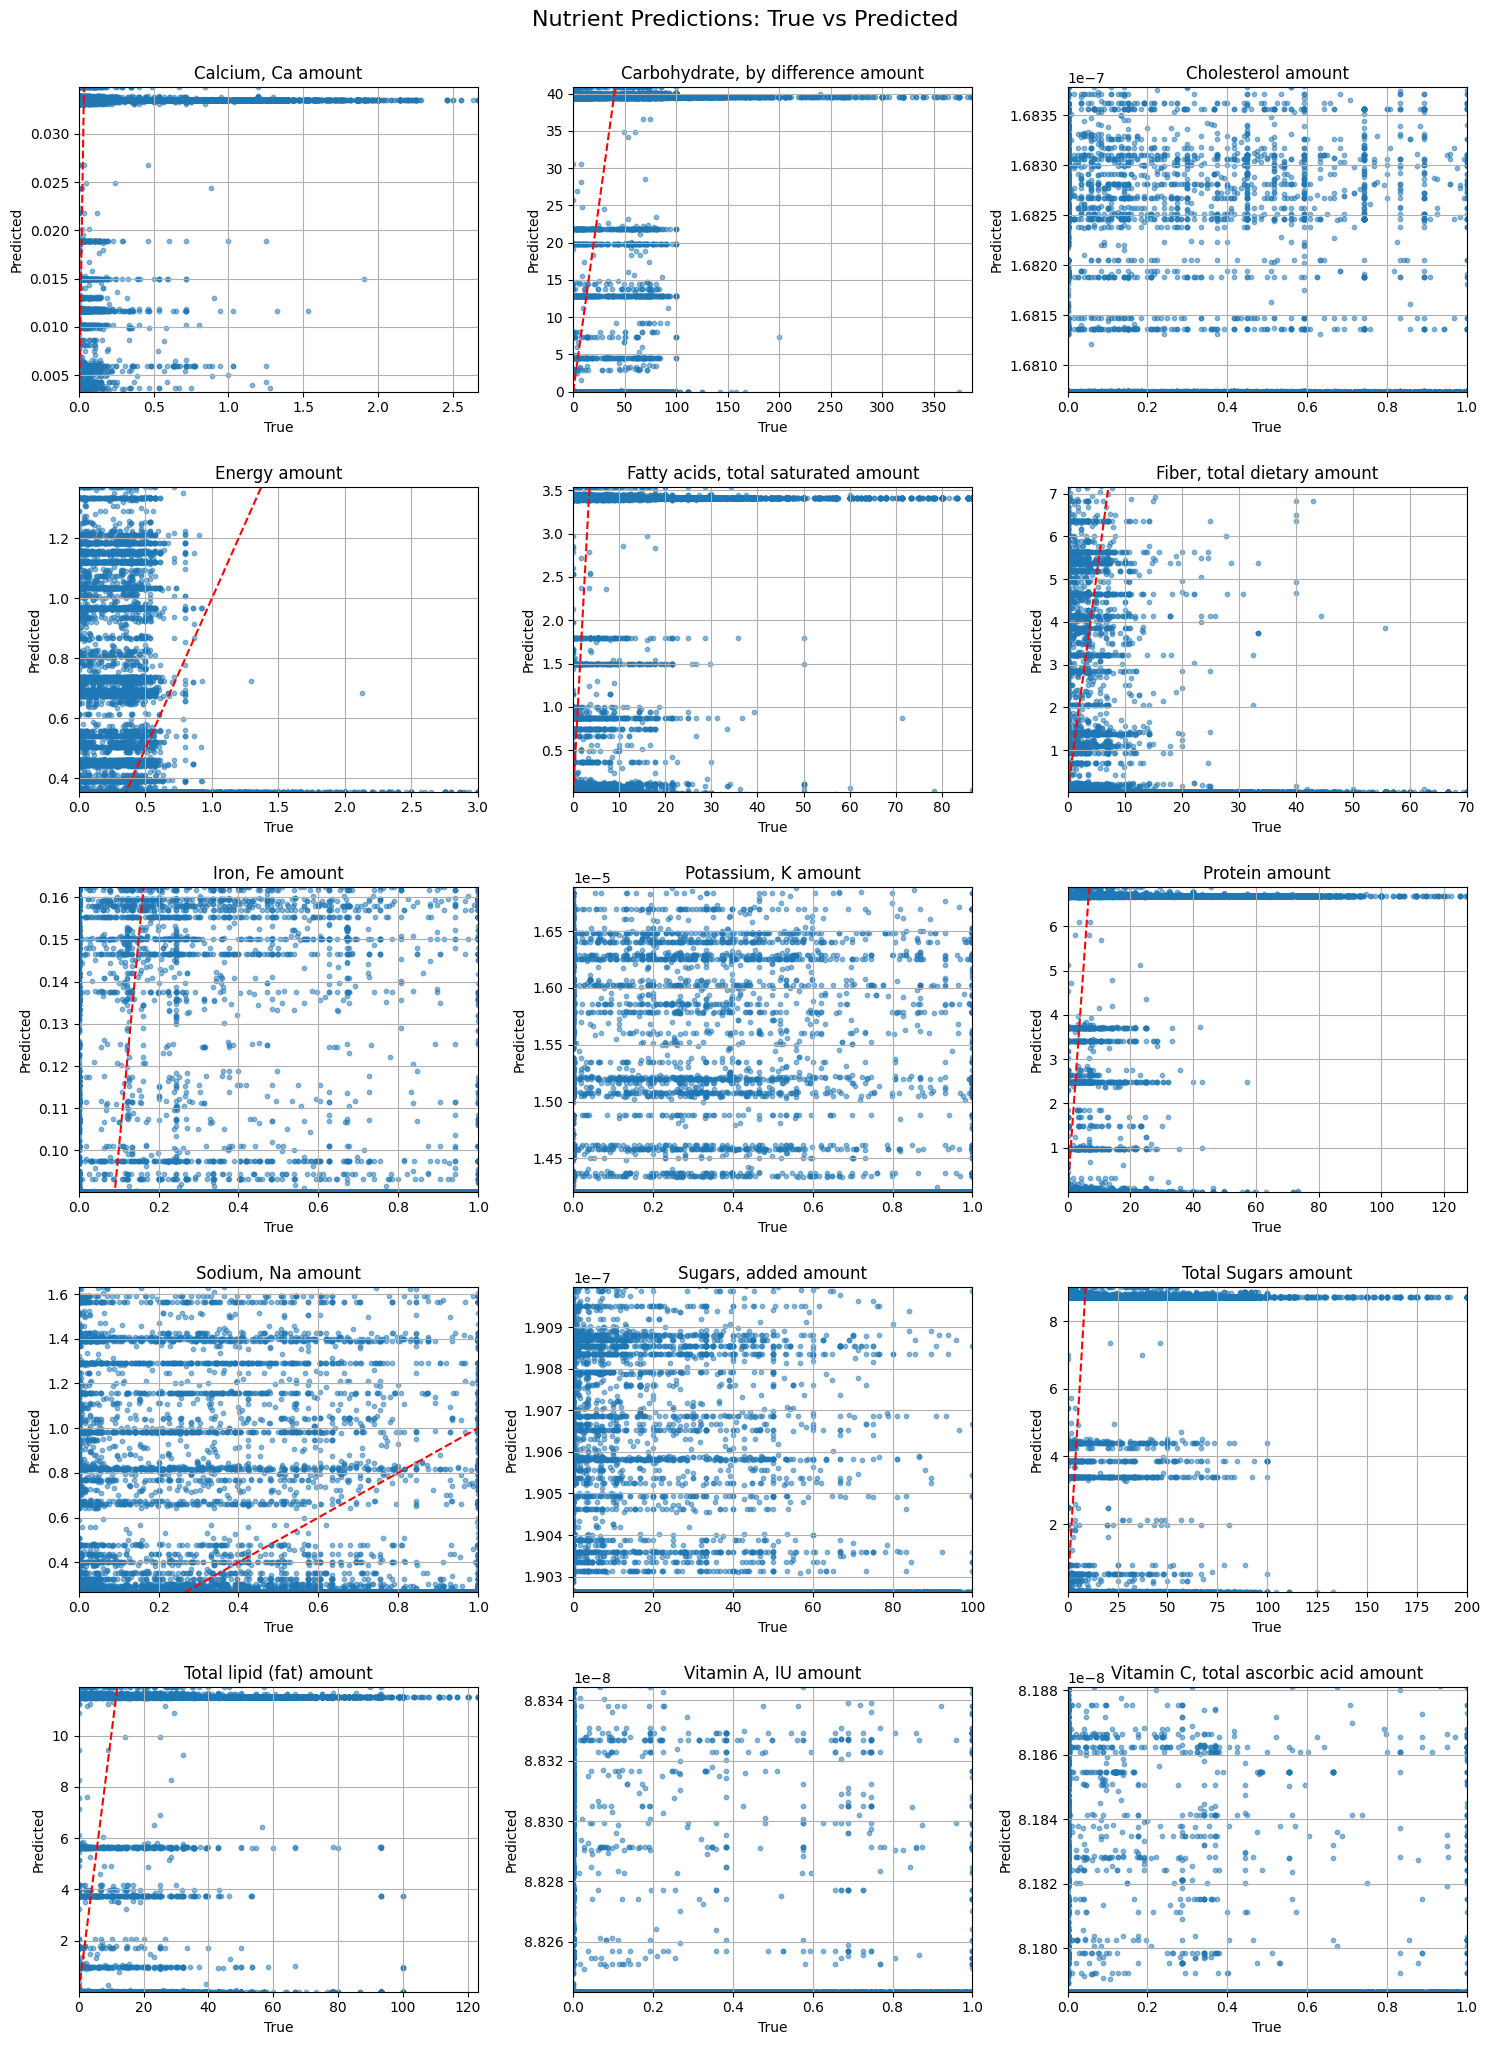

In [15]:
# Visualize all nutrient predictions: scatter plots with prediction line in subplots
num_nutrients = len(nutrient_cols)
cols = 3
rows = int(np.ceil(num_nutrients / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):
    ax = axes[i]
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=10)
    min_val = min(np.min(y_true[:, i]), np.min(y_pred[:, i]))
    max_val = max(np.max(y_true[:, i]), np.max(y_pred[:, i]))
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    true_1p = np.percentile(y_true[:, i], 1)
    true_99p = np.percentile(y_true[:, i], 99.95)
    pred_1p = np.percentile(y_pred[:, i], 1)
    pred_99p = np.percentile(y_pred[:, i], 99.95)
    ax.set_xlim(true_1p, true_99p)
    ax.set_ylim(pred_1p, pred_99p)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.set_title(col)
    ax.grid(True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Nutrient Predictions: True vs Predicted', y=1.02, fontsize=16)
plt.show()

### Evaluation Summary: MAE vs MSE Loss
**MAE Loss:**
- Mean RMSE: 11.00, Median RMSE: 5.26
- Mean MAE: 5.05, Median MAE: 0.26
- MAE is less sensitive to outliers, resulting in lower mean and median errors compared to RMSE.

- MAE provides a more robust measure of average error, especially when outliers are present, while RMSE highlights the impact of large errors.

**R² (R Squared):**
Mean R^2: -0.1220
Median R^2: -0.0645
- R² values are negative for both MAE and MSE, indicating the model does not explain the variance in the nutrient data better than a mean predictor.
- Again, this may be because R² is not a viable metric for LSTM, but it was included anyways because the data is very high in variance.

**Residuals:**
Mean residual (MAE): 0.5615, Median residual (MAE): -0.0000
Mean residual (MSE): 0.2414, Median residual (MSE): -0.1219
- MAE loss produces smaller residual ranges, indicating less impact from extreme outliers.
- MSE loss has larger residuals, as it penalizes large errors more heavily, which can skew the model toward fitting outliers.

**Conclusion:**
- MAE is preferable when outliers are present and a robust average error is desired.
- MSE is better when it is important to penalize large errors and capture variance, but can be dominated by outliers.
- In this dataset, MAE yields lower average errors and residuals.